# Step 1: Create Universe and Returns
This notebook loads the historical Yahoo Finance data and calculates the tradable universe based on Average Daily Volume (ADV) constraints, as well as the daily returns.

In [2]:
import pandas as pd
import os

DATA_DIR = "stores"
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('top_5000_yf_data.pkl')
print('Data loaded successfully.')

Loading top_5000_yf_data.pkl...
Data loaded successfully.


In [4]:
# 1. Calculate Average Daily Volume (ADV) for trailing 60 days\n,
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=60).mean()
# 2. Price constraint
price_mask = df_historical['Close'] >= 1
# 3. ER (Efficiency Ratio) <= 0.25
# ER = absolute net change over 60 days / sum of absolute daily changes over 60 days\n",
net_change = df_historical['Close'].diff(60).abs()
sum_abs_daily_change = df_historical['Close'].diff().abs().rolling(window=60, min_periods=60).sum()
er = net_change / sum_abs_daily_change
er_mask = er <= 0.25
# 4. Volatility >= median\n",
# Volatility as 60-day rolling std of daily returns\n",
daily_ret = df_historical['Close'].pct_change()
vol_60 = daily_ret.rolling(window=60, min_periods=60).std()
median_vol = vol_60.median(axis=1)
# Compare each stock's volatility to the cross-sectional median for that day\n",
vol_mask = vol_60.ge(median_vol, axis=0)

C:\Users\USER\AppData\Local\Temp\ipykernel_34088\4018477625.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret = df_historical['Close'].pct_change()


Universe shape: (4117, 5002)


<Axes: title={'center': 'Number of Tradable Stocks Over Time'}, xlabel='Date'>

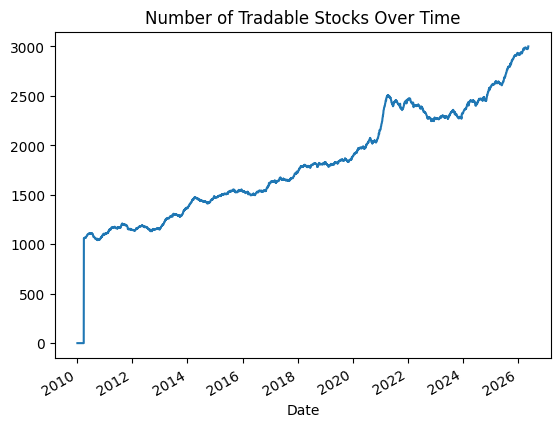

In [5]:
# Creating Universe based on all constraints
df_universe_5m = ((df_adv_60 >= 5_000_000)).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time")


<Axes: title={'center': 'Number of Tradable Stocks (2021-2026)'}, xlabel='Date'>

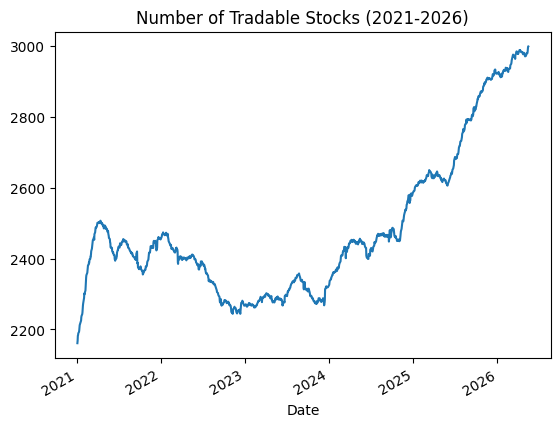

In [6]:
df_universe_2021_2026 = df_universe_5m.loc['2021':'2026']
df_universe_2021_2026.sum(axis=1).plot(title="Number of Tradable Stocks (2021-2026)")

In [7]:
# Keep only the stocks that are present (value == 1) continuously from 2021 to 2026
continuous_stocks = df_universe_2021_2026.columns[df_universe_2021_2026.all()]
df_universe_continuous = df_universe_2021_2026[continuous_stocks]

print(f"Number of continuous stocks: {len(continuous_stocks)}")
df_universe_continuous.head()

Number of continuous stocks: 1677


Ticker,A,AA,AAL,AAON,AAP,AAPL,AAT,AB,ABBV,ABCB,...,ZBRA,ZD,ZG,ZION,ZLAB,ZM,ZS,ZTO,ZTS,ZWS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2021-01-05,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2021-01-06,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2021-01-07,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2021-01-08,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [8]:
# Saving 5M universe to stores folder
# Drop any duplicated columns
df_universe_5m = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]
df_universe_5m.to_parquet(os.path.join(DATA_DIR, 'universe_5m.parquet'), engine='pyarrow')
print('Saved universe_5m.parquet')


Saved universe_5m.parquet


In [9]:
# Calculating returns for each ticker every day
# Using Adj Close to account for dividends and stock splits
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)

In [10]:
# Saving returns to parquet file
# Drop any duplicated columns
returns = returns.loc[:, ~returns.columns.duplicated()]
returns.to_parquet(os.path.join(DATA_DIR, 'returns.parquet'), engine='pyarrow')
print('Saved returns.parquet')

Saved returns.parquet


In [16]:
import pandas as pd

# 1. Load the stock metadata containing the sectors
meta_df = pd.read_csv('top_5000_us_by_marketcap.csv')

# Normalize the ticker symbols to match Yahoo Finance format 
# (e.g., replacing 'BRK/B' from the CSV to 'BRK-B' to match your 'continuous_stocks')
meta_df['symbol'] = meta_df['symbol'].str.replace('/', '-')

# 2. Filter for the 1677 continuous stocks
# (This uses the 'continuous_stocks' variable you defined in the previous cell)
consistent_df = meta_df[meta_df['symbol'].isin(continuous_stocks)].copy()

# 3. Sort/Group the dataframe by 'sector' and then by 'symbol'
grouped_by_sector = consistent_df.sort_values(by=['sector', 'symbol'])

# Optional: If you want a cleaner CSV with only the most important columns, uncomment the line below:
# grouped_by_sector = grouped_by_sector[['symbol', 'name', 'sector', 'industry', 'marketCap']]

# 4. Save to CSV
output_filename = 'consistent_1677_stocks_by_sector.csv'
grouped_by_sector.to_csv(output_filename, index=False)

print(f"Successfully saved {len(grouped_by_sector)} stocks grouped by sector to '{output_filename}'")


Successfully saved 1677 stocks grouped by sector to 'consistent_1677_stocks_by_sector.csv'


In [17]:
# Groups stocks into a comma-separated string per sector
sector_summary = consistent_df.groupby('sector')['symbol'].apply(lambda x: ', '.join(x)).reset_index()
sector_summary.rename(columns={'symbol': 'stocks'}, inplace=True)
sector_summary.to_csv('sector_summary_list.csv', index=False)
print("Saved sector summary!")


Saved sector summary!


In [18]:
for sector, group in consistent_df.groupby('sector'):
    print(f"Sector: {sector}, Number of Stocks: {len(group)}")

Sector: Basic Materials, Number of Stocks: 37
Sector: Consumer Discretionary, Number of Stocks: 338
Sector: Consumer Staples, Number of Stocks: 53
Sector: Energy, Number of Stocks: 69
Sector: Finance, Number of Stocks: 250
Sector: Health Care, Number of Stocks: 193
Sector: Industrials, Number of Stocks: 239
Sector: Miscellaneous, Number of Stocks: 10
Sector: Real Estate, Number of Stocks: 147
Sector: Technology, Number of Stocks: 231
Sector: Telecommunications, Number of Stocks: 31
Sector: Utilities, Number of Stocks: 76


In [19]:
import numpy as np
import pandas as pd
import os

# 1. Compute the daily log returns for the continuous stocks from 2021 to 2026
adj_close = df_historical['Adj Close'][continuous_stocks].loc['2021':'2026']

# Log return = ln(Price_today / Price_yesterday)
log_returns = np.log(adj_close / adj_close.shift(1))
log_returns = log_returns.dropna(how='all').fillna(0) # Drop the first NaN row and fill remaining with 0

sector_factors_dict = {}
sector_eigenvalues = {}
sector_eigenvectors = {}

for sector, group in consistent_df.groupby('sector'):
    tickers = group['symbol'].tolist()
    # Filter for tickers to ensure they exist in our log returns
    valid_tickers = [t for t in tickers if t in log_returns.columns]
    
    if not valid_tickers:
        continue
        
    sector_ret = log_returns[valid_tickers]
    
    # 2. Normalize the returns cross-sectionally in each of these sectors
    # For each date (row), subtract the mean and divide by the standard deviation of that day's returns
    mean_cross = sector_ret.mean(axis=1)
    std_cross = sector_ret.std(axis=1).replace(0, np.nan) # Replace 0 with NaN to avoid division by zero errors
    
    sector_ret_norm = sector_ret.sub(mean_cross, axis=0).div(std_cross, axis=0).fillna(0)
    
    # 3. Compute the covariance matrix for each of these sectors
    cov_matrix = sector_ret_norm.cov()
    
    # 4. Find the eigenvalues and the eigenvectors
    # np.linalg.eigh is optimized for symmetric matrices like covariance matrices
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # np.linalg.eigh returns them in ascending order, so we reverse them to descending order
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    sector_eigenvalues[sector] = eigenvalues
    sector_eigenvectors[sector] = eigenvectors
    
    # 5. Create continuous independent factors
    # The continuous factors are the projection of the normalized returns onto the eigenvectors (X * W)
    factors = sector_ret_norm.dot(eigenvectors)
    
    # Rename columns to identify which factor belongs to which sector
    factors.columns = [f"{sector}_Factor_{i+1}" for i in range(factors.shape[1])]
    
    sector_factors_dict[sector] = factors

# Combine all generated sector factors into a single DataFrame
all_sector_factors = pd.concat(sector_factors_dict.values(), axis=1)

print("Calculated PCA factors for all sectors.")
print(f"Total shape of all combined factors: {all_sector_factors.shape}")

# Optional: Save the computed factors to the stores directory
all_sector_factors.to_parquet(os.path.join(DATA_DIR, 'sector_pca_factors.parquet'), engine='pyarrow')
print("Saved sector_pca_factors.parquet")


Calculated PCA factors for all sectors.
Total shape of all combined factors: (1347, 1674)
Saved sector_pca_factors.parquet


In [27]:
# Save your pristine 274 pairs to load into your live trading script
df_final_pairs.to_csv("kalman_universe_config.csv", index=False)

In [15]:
import numpy as np
import pandas as pd
import statsmodels.tsa.stattools as ts
from scipy.odr import Model, Data, ODR
import itertools
from IPython.display import display

# ==============================================================================
# 1. TOTAL LEAST SQUARES (TLS) & COINTEGRATION ENGINE
# ==============================================================================
def linear_func(B, x):
    """Linear model for Orthogonal Distance Regression: y = Beta * x + Alpha"""
    return B[0] * x + B[1]

def run_tls_adf(y, x):
    # Align and drop NaNs/Infs
    aligned_data = pd.concat([y, x], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    
    # Require at least 200 trading days out of the 12-month (252 day) window
    if len(aligned_data) < 200: 
        return 1.0, None, None, None
        
    y_clean = aligned_data.iloc[:, 0].values
    x_clean = aligned_data.iloc[:, 1].values
    
    # ---------------------------------------------------------
    # THE TLS UPGRADE: Eliminating OLS Attenuation Bias
    # SciPy's ODR accounts for variance (noise) in BOTH X and Y
    # ---------------------------------------------------------
    linear_model = Model(linear_func)
    data = Data(x_clean, y_clean)
    odr_obj = ODR(data, linear_model, beta0=[1.0, 0.0])
    res = odr_obj.run()
    
    beta, alpha = res.beta
    
    # Calculate the residuals using the unbiased TLS Beta
    residuals = y_clean - (beta * x_clean + alpha)
    residuals_series = pd.Series(residuals, index=aligned_data.index)
    
    # ADF Test on the TLS residuals
    adf_result = ts.adfuller(residuals_series, maxlag=1)
    
    return adf_result[1], beta, alpha, residuals_series

def calculate_half_life(residuals_series):
    delta_res = residuals_series.diff().dropna()
    lagged_res = residuals_series.shift(1).dropna().loc[delta_res.index]
    
    # Standard OLS is fine here because we are regressing a clean lag against itself
    lagged_vals = lagged_res.values
    delta_vals = delta_res.values
    
    # Calculate slope manually for speed: sum(xy) / sum(x^2)
    x_mean = np.mean(lagged_vals)
    y_mean = np.mean(delta_vals)
    numerator = np.sum((lagged_vals - x_mean) * (delta_vals - y_mean))
    denominator = np.sum((lagged_vals - x_mean)**2)
    
    if denominator == 0: return np.inf
    lam = numerator / denominator
    
    if lam >= 0: return np.inf
    return -np.log(2) / lam

# ==============================================================================
# 2. THE FUNDAMENTAL UNIVERSE (12-Month Horizon)
# ==============================================================================
# Assuming df_historical is loaded
end_date = df_historical.index.max()
end_date = end_date - pd.DateOffset(months=6)
start_date = end_date - pd.DateOffset(months=12) # Strict 12-month empirical parameter stability

print(f"Formation Window: {start_date.date()} to {end_date.date()}")
df_window = df_historical.loc[start_date:end_date]

daily_dollar_vol = df_window['Close'].mul(df_window['Volume']).fillna(0)
mean_dollar_vol = daily_dollar_vol.mean()
mean_adj_close = df_window['Adj Close'].mean()

liquid_universe = mean_dollar_vol[(mean_dollar_vol > 5_000_000) & (mean_adj_close >= 1)].index.tolist()

meta_df = pd.read_csv('top_5000_us_by_marketcap.csv')
meta_df['symbol'] = meta_df['symbol'].str.replace('/', '-')

# Clean the industry data (Drop blanks or 'Unknown')
meta_df = meta_df.dropna(subset=['industry'])
meta_df = meta_df[meta_df['industry'] != '']

dynamic_consistent_df = meta_df[meta_df['symbol'].isin(liquid_universe)].copy()

adj_close_window = df_window['Adj Close'][liquid_universe]
log_prices = np.log(adj_close_window).dropna(how='all').ffill()

# ==============================================================================
# 3. STAT-ARB SEARCH (Economics-First Parameters)
# ==============================================================================
# The Institutional Thresholds
MAX_P_VALUE = 0.0027          # Harvey's strict t-stat > 3.0 equivalent
MIN_HALF_LIFE = 2.0           # Beat microstructure noise
MAX_HALF_LIFE = 10.0          # Must revert within our 1-month competition
MIN_SPREAD_VOL = 0.0010       # 2.5x the 4bps round-trip transaction costs
PEARSON_THRESHOLD = 0.50      # Must have fundamentally correlated daily returns

valid_pairs = []
residuals_dict = {}

# THE BOUNDING BOX: Grouping strictly by the granular Industry column
for industry, group in dynamic_consistent_df.groupby('industry'):
    tickers = [t for t in group['symbol'].tolist() if t in log_prices.columns]
    if len(tickers) < 2: continue
        
    sector_prices = log_prices[tickers]
    pairs = list(itertools.combinations(tickers, 2))
    
    # Vectorized Pre-Filter on RETURNS
    returns_corr_matrix = sector_prices.diff().dropna().corr().abs()
    
    for y_ticker, x_ticker in pairs:
        if returns_corr_matrix.loc[y_ticker, x_ticker] < PEARSON_THRESHOLD:
            continue
            
        y = sector_prices[y_ticker]
        x = sector_prices[x_ticker]
        
        p_value, beta, alpha, residuals = run_tls_adf(y, x)
        
        if p_value > MAX_P_VALUE or residuals is None: 
            continue
            
        half_life = calculate_half_life(residuals)
        if not (MIN_HALF_LIFE <= half_life <= MAX_HALF_LIFE): 
            continue
            
        spread_volatility = residuals.std()
        if spread_volatility <= MIN_SPREAD_VOL: 
            continue
        
        # The beta must be positive, and neither asset should be 
        # leveraged more than 3x against the other.
        if not (0.33 <= beta <= 3.0):
            continue
        # Cap the maximum spread variance to prevent meme/micro-cap traps
        MAX_SPREAD_VOL = 0.08 # 8% daily volatility limit
        if spread_volatility > MAX_SPREAD_VOL:
            continue
        
        pair_name = f"{y_ticker}_{x_ticker}"
        valid_pairs.append({
            'pair_name': pair_name,
            'industry': industry,
            'asset_y': y_ticker,
            'asset_x': x_ticker,
            'tls_beta': beta, 
            'adf_p_value': p_value,
            'half_life_days': half_life,
            'spread_vol': spread_volatility
        })
        residuals_dict[pair_name] = residuals

df_final_pairs = pd.DataFrame(valid_pairs)

# ==============================================================================
# 4. DE-DUPLICATION (Risk Matrix)
# ==============================================================================
if not df_final_pairs.empty:
    df_final_pairs = df_final_pairs.sort_values(by=['adf_p_value']).head(500)
    
    top_pair_names = df_final_pairs['pair_name'].tolist()
    filtered_residuals = {k: residuals_dict[k] for k in top_pair_names}
    
    df_residuals = pd.DataFrame(filtered_residuals)
    corr_matrix = df_residuals.corr().abs()
    
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = []
    
    for column in upper_tri.columns:
        correlated_with_col = upper_tri.index[upper_tri[column] > 0.60].tolist()
        if correlated_with_col:
            pair_1 = column
            pair_2 = correlated_with_col[0] 
            
            p_val_1 = df_final_pairs[df_final_pairs['pair_name'] == pair_1]['adf_p_value'].values[0]
            p_val_2 = df_final_pairs[df_final_pairs['pair_name'] == pair_2]['adf_p_value'].values[0]
            
            if p_val_1 > p_val_2: to_drop.append(pair_1)
            else: to_drop.append(pair_2)
                
    to_drop = list(set(to_drop))
    df_final_pairs = df_final_pairs[~df_final_pairs['pair_name'].isin(to_drop)].drop(columns=['pair_name']).reset_index(drop=True)

print(f"\n==========================================================")
print(f"Institutional Pipeline completed! Final Cointegrated Pairs: {len(df_final_pairs) if not df_final_pairs.empty else 0}")
print(f"==========================================================\n")

if not df_final_pairs.empty:
    display(df_final_pairs.head(20))

Formation Window: 2024-11-15 to 2025-11-15

Institutional Pipeline completed! Final Cointegrated Pairs: 139



,industry,asset_y,asset_x,tls_beta,adf_p_value,half_life_days,spread_vol
0,Major Banks,PNC,ZION,0.899869,7.654989e-07,2.969677,0.016728
1,Containers/Packaging,CCK,OI,0.724593,6.365275e-06,3.721530,0.028696
2,Industrial Machinery/Components,KEYS,AME,1.502563,7.027222e-06,4.867005,0.038384
3,Real Estate,TRNO,CURB,2.281628,7.657648e-06,3.476580,0.044991
4,Real Estate Investment Trusts,NNN,ALX,0.371231,1.171072e-05,3.583443,0.019436
5,Industrial Machinery/Components,TRMB,AGCO,1.072852,1.380772e-05,3.676669,0.038005
6,Major Banks,USB,CATY,1.085074,2.838619e-05,4.054048,0.022046
7,Marine Transportation,SBLK,GSL,0.579451,2.871370e-05,5.919741,0.046798
8,Major Banks,RF,KEY,1.104934,2.937587e-05,3.819975,0.015751
9,Marine Transportation,CCL,CUK,0.981617,3.530185e-05,3.879093,0.005355


In [26]:
# ==============================================================================
# 5. THE HUMAN BLACKLIST (Qualitative Pruning)
# ==============================================================================

# The specific indices of pairs containing fundamental/macro mismatches
blacklist_indices = [
    22, 26, 36, 41, 42, 49, 51, 52, 54, 58, 
    65, 72, 73, 74, 78, 82, 90, 91, 93, 94, 99, 
    103, 105, 111, 112, 115, 116, 118, 120, 124, 130, 133, 134
]

# Drop the anomalous pairs 
df_final_pairs = df_final_pairs.drop(index=blacklist_indices)

# Reset the index so the Kalman Filter loop processes it cleanly
df_final_pairs = df_final_pairs.reset_index(drop=True)

print(f"Removed {len(blacklist_indices)} structural traps.")
print(f"Final Institutional Portfolio Size: {len(df_final_pairs)} pairs ready for execution.")

Removed 33 structural traps.
Final Institutional Portfolio Size: 106 pairs ready for execution.


In [28]:
import pandas as pd
import numpy as np

def analyze_portfolio_risk(df):
    print("==========================================================")
    print(" 🏦 PORTFOLIO RISK CONCENTRATION AUDIT")
    print("==========================================================")
    
    # 1. Basic Universe Metrics
    total_pairs = len(df)
    all_tickers = pd.concat([df['asset_y'], df['asset_x']])
    unique_tickers = all_tickers.nunique()
    
    print(f"Total Tradable Pairs: {total_pairs}")
    print(f"Unique Stocks Deployed: {unique_tickers}")
    print(f"Capital Efficiency (Pairs per Stock): {total_pairs / unique_tickers:.2f}\n")

    # 2. Single-Stock Over-Exposure (The "Pinch Point" Check)
    print("----------------------------------------------------------")
    print(" ⚠️ TOP 10 MOST CONCENTRATED STOCKS (Risk Check)")
    print("----------------------------------------------------------")
    ticker_counts = all_tickers.value_counts()
    for ticker, count in ticker_counts.head(10).items():
        percentage = (count / total_pairs) * 100
        print(f"  {ticker.ljust(6)} : Appears in {count} pairs ({percentage:.1f}% of portfolio)")
        
    if ticker_counts.max() > (total_pairs * 0.10):
        print("\n  [WARNING]: You have a stock representing >10% of your pairs.")
        print("  If this stock halts or has an idiosyncratic shock, the portfolio will suffer.")

    # 3. Industry Allocation
    print("\n----------------------------------------------------------")
    print(" 🏭 INDUSTRY ALLOCATION (Where is the capital going?)")
    print("----------------------------------------------------------")
    industry_counts = df['industry'].value_counts()
    for ind, count in industry_counts.head(10).items():
        percentage = (count / total_pairs) * 100
        print(f"  {ind[:40].ljust(40)} : {count} pairs ({percentage:.1f}%)")

    # 4. Thermodynamic Health (The Engine Stats)
    print("\n----------------------------------------------------------")
    print(" ⚙️ THERMODYNAMIC HEALTH SUMMARY")
    print("----------------------------------------------------------")
    
    # Beta distribution (Are we skewing long or short?)
    median_beta = df['tls_beta'].median()
    print(f"  Median TLS Beta:       {median_beta:.3f} (Ideal is ~1.0)")
    
    # Velocity (How fast is capital recycling?)
    median_hl = df['half_life_days'].median()
    fastest_hl = df['half_life_days'].min()
    print(f"  Median Half-Life:      {median_hl:.1f} days")
    print(f"  Fastest Reverting:     {fastest_hl:.1f} days")
    
    # Volatility Envelope (Are spreads wide enough to beat fees?)
    median_vol = df['spread_vol'].median()
    max_vol = df['spread_vol'].max()
    print(f"  Median Spread Vol:     {(median_vol * 100):.2f}%")
    print(f"  Maximum Spread Vol:    {(max_vol * 100):.2f}%")
    
    print("==========================================================\n")

# Run the analyzer on your cleaned dataframe
analyze_portfolio_risk(df_final_pairs)

 🏦 PORTFOLIO RISK CONCENTRATION AUDIT
Total Tradable Pairs: 106
Unique Stocks Deployed: 169
Capital Efficiency (Pairs per Stock): 0.63

----------------------------------------------------------
 ⚠️ TOP 10 MOST CONCENTRATED STOCKS (Risk Check)
----------------------------------------------------------
  WAL    : Appears in 5 pairs (4.7% of portfolio)
  BANR   : Appears in 5 pairs (4.7% of portfolio)
  KEY    : Appears in 4 pairs (3.8% of portfolio)
  THG    : Appears in 3 pairs (2.8% of portfolio)
  FULT   : Appears in 3 pairs (2.8% of portfolio)
  FFBC   : Appears in 3 pairs (2.8% of portfolio)
  CATY   : Appears in 3 pairs (2.8% of portfolio)
  TCBI   : Appears in 3 pairs (2.8% of portfolio)
  OGE    : Appears in 3 pairs (2.8% of portfolio)
  FITB   : Appears in 2 pairs (1.9% of portfolio)

----------------------------------------------------------
 🏭 INDUSTRY ALLOCATION (Where is the capital going?)
----------------------------------------------------------
  Major Banks            

In [29]:
import numpy as np
import pandas as pd

class InstitutionalKalmanFilter:
    def __init__(self, initial_beta, spread_vol):
        # 1. State Vector: [Alpha, Beta]. Seeded perfectly from our TLS Phase.
        self.theta = np.array([[0.0], [initial_beta]])
        
        # 2. State Covariance (Uncertainty). Moderate start to allow slight Day-1 adaptation.
        self.P = np.zeros((2, 2))
        np.fill_diagonal(self.P, 1.0)
        
        # 3. Measurement Noise. Anchored exactly to the empirical variance of the asset.
        self.R = spread_vol ** 2
        
        # 4. Process Noise. Very low. We trust our fundamental pairing.
        self.Q = np.zeros((2, 2))
        np.fill_diagonal(self.Q, 1e-5)
        
        # Store initial beta for the Guardrail check
        self.anchor_beta = initial_beta
        
        self.current_spread = 0.0
        self.z_score = 0.0

    def step(self, log_price_y, log_price_x):
        # Observation Matrix
        H = np.array([[1.0, log_price_x]])
        
        # --- PREDICT STEP ---
        theta_pred = self.theta
        P_pred = self.P + self.Q
        y_pred = H @ theta_pred
        
        # Error / Spread
        e = log_price_y - y_pred[0, 0]
        self.current_spread = e
        
        # Prediction Variance
        S = H @ P_pred @ H.T + self.R
        prediction_variance = S[0, 0]
        
        # The Golden Signal
        self.z_score = e / np.sqrt(prediction_variance)
        
        # --- UPDATE STEP ---
        # Kalman Gain (How much do we trust the new error vs our old state?)
        K = (P_pred @ H.T) / prediction_variance
        
        self.theta = theta_pred + K * e
        self.P = (np.eye(2) - K @ H) @ P_pred
        
        current_beta = self.theta[1, 0]
        
        return self.z_score, current_beta


def execute_qrt_portfolio(df_final_pairs, oos_prices):
    """
    Simulates daily OOS execution, applies Risk Parity, and outputs 
    the normalized GMV=1.0 weight matrix for the QRT Backtester.
    """
    print(f"Spinning up {len(df_final_pairs)} Kalman Filters for OOS Execution...")
    
    active_filters = {}
    for _, row in df_final_pairs.iterrows():
        active_filters[row['pair_name']] = InstitutionalKalmanFilter(
            initial_beta=row['tls_beta'], 
            spread_vol=row['spread_vol']
        )
        
    # The output weight matrix (Dates x Tickers)
    portfolio_weights = pd.DataFrame(0.0, index=oos_prices.index, columns=oos_prices.columns)
    
    # State tracking: 0=Flat, 1=Long Spread, -1=Short Spread
    positions = {pair: 0 for pair in active_filters.keys()}
    
    for i in range(1, len(oos_prices.index)):
        today = oos_prices.index[i]
        
        for pair_name, kf in active_filters.items():
            y_ticker, x_ticker = pair_name.split('_')
            
            p_y = oos_prices.loc[today, y_ticker]
            p_x = oos_prices.loc[today, x_ticker]
            
            # Liquidity Check: If data is missing/NaN, flatten the position
            if pd.isna(p_y) or pd.isna(p_x):
                positions[pair_name] = 0
                continue
                
            # Step the filter
            z_score, current_beta = kf.step(np.log(p_y), np.log(p_x))
            
            # -------------------------------------------------------------
            # THE BETA GUARDRAIL (Critical Risk Management)
            # If dynamic beta drifts > 40% from the fundamental anchor, 
            # the structural relationship is broken. Flatten and ignore.
            # -------------------------------------------------------------
            if abs((current_beta - kf.anchor_beta) / kf.anchor_beta) > 0.40:
                positions[pair_name] = 0
                continue
            
            # -------------------------------------------------------------
            # TRADING LOGIC
            # -------------------------------------------------------------
            pos = positions[pair_name]
            
            # Enter at 2.0 Sigma, Exit exactly at 0.0 (Mean Reversion)
            if z_score > 2.0 and pos == 0:
                pos = -1 
            elif z_score < -2.0 and pos == 0:
                pos = 1  
            elif pos == -1 and z_score < 0:
                pos = 0  
            elif pos == 1 and z_score > 0:
                pos = 0  
                
            positions[pair_name] = pos
            
            # -------------------------------------------------------------
            # CAPITAL ALLOCATION (Risk Parity)
            # -------------------------------------------------------------
            if pos != 0:
                # Target capital is inverse to the spread's volatility (R)
                # This ensures a 6% vol pair doesn't dominate a 2% vol pair
                target_capital = 1.0 / np.sqrt(kf.R) 
                
                # Spread Definition: 1 unit of Y, -Beta units of X
                if pos == 1: # Long the Spread
                    portfolio_weights.loc[today, y_ticker] += target_capital
                    portfolio_weights.loc[today, x_ticker] -= target_capital * current_beta
                elif pos == -1: # Short the Spread
                    portfolio_weights.loc[today, y_ticker] -= target_capital
                    portfolio_weights.loc[today, x_ticker] += target_capital * current_beta

    print("Enforcing Unit Capital Constraint (Gross Exposure = 1.0)...")
    
    # Absolute sum of all weights for each day
    daily_gross_exposure = portfolio_weights.abs().sum(axis=1)
    
    # Prevent Division by Zero on days where no signals triggered
    daily_gross_exposure = daily_gross_exposure.replace(0, 1) 
    
    # Normalize every row so the absolute sum equals exactly 1.0
    normalized_portfolio = portfolio_weights.div(daily_gross_exposure, axis=0).fillna(0)
    
    return normalized_portfolio